# Hypothesis Testing – Quantitative Impact of Global and Domestic Events on the BIST 100
This notebook implements the statistical hypothesis testing part of the project.
While exploratory data analysis (EDA) visually suggests that macro-shocks disrupt the market, we must mathematically prove that these observations are not just random noise.

We use two processed datasets for this analysis:
`unified_bist_data.csv` – daily market panel with:
* `daily_return_pct` – The percentage change in the closing price of the BIST 100 index.
* `is_shock` – A binary indicator (1 representing a shock day, 0 representing a normal trading day).

`shock_analysis_summary.csv` – event-level panel with:
* `severity` – Categorized impact level of the shock (Moderate, High, Extreme).

We test the following core hypotheses:
* **H1:** The distribution of daily returns on shock days is fundamentally different from normal trading days.
* **H2:** Macroeconomic and geopolitical shocks systematically increase the volatility (variance) of the market.
* **H3:** The magnitude of the market reaction depends strictly on the categorized severity of the external shock.
* **H4:** The market exhibits a "hangover" effect, where negative pressure on returns continues into the trading session immediately following a shock (T+1).


# [1] Data Loading and Temporal Alignment
This section integrates daily market data with a curated list of external shock events. A key focus is **Temporal Alignment**: ensuring shocks that occur on weekends or holidays are correctly mapped to the next available trading session.

**Key Operations:**
* **Source Integration:** Merging `unified_bist_data.csv` and `shock_analysis_summary.csv`.
* **Forward Alignment:** Using a "Nearest Forward" strategy to capture the actual market reaction on the first available trading day.
* **Feature Engineering:** Integrating the `severity` index into the daily time-series for categorical analysis.

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import statsmodels.formula.api as smf
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plotting configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

# Load Data (Handling relative paths safely)
DATA_DIR = Path("..") / "data_collection" / "processed"
try:
    df_daily = pd.read_csv(DATA_DIR / "unified_bist_data.csv")
    df_shocks = pd.read_csv(DATA_DIR / "shock_analysis_summary.csv")
    print("✅ SUCCESS: Files loaded from 'data collection/processed'!")
except FileNotFoundError:
    DATA_DIR = Path("..") / "data collection"
    df_daily = pd.read_csv(DATA_DIR / "unified_bist_data.csv")
    df_shocks = pd.read_csv(DATA_DIR / "shock_analysis_summary.csv")
    print("✅ SUCCESS: Files loaded directly from 'data collection'!")

# Preprocessing: Convert dates to align dataframes
df_daily['date'] = pd.to_datetime(df_daily['date'])
df_shocks['date'] = pd.to_datetime(df_shocks['date'])

# Merge severity index into the main daily dataset
df = pd.merge(df_daily, df_shocks[['date', 'severity']], on='date', how='left')
df['severity'] = df['severity'].fillna('Normal')

print(f"Data ready. Total Rows: {len(df)}")

✅ SUCCESS: Files loaded from 'data collection/processed'!
Data ready. Total Rows: 2817


## H1 – Market Return Distribution Shift
**Hypothesis**
* **H1:** The distribution of daily returns on macro-shock days is fundamentally different from the distribution on normal trading days.
* **H0:** There is no systematic difference in the return distributions between normal days and shock days.

We use the `daily_return_pct` variable grouped by the `is_shock` flag.

**Methodological Approach:**
Because financial returns often exhibit "fat tails" and do not perfectly follow a normal distribution, we avoid standard parametric tests (like the Student's t-test). Instead, we use the **Mann-Whitney U Test** (a robust, non-parametric test) to compare the two independent samples. We visualize this shift using Kernel Density Estimation (KDE).


--- HYPOTHESIS 1: DISTRIBUTION SHIFT ---
Test: Mann-Whitney U [Median(Shock) vs Median(Normal)]
U-Statistic: 17883.0
P-Value:     3.378634e-02
✅ RESULT: Statistically Significant. The return distributions are fundamentally different.


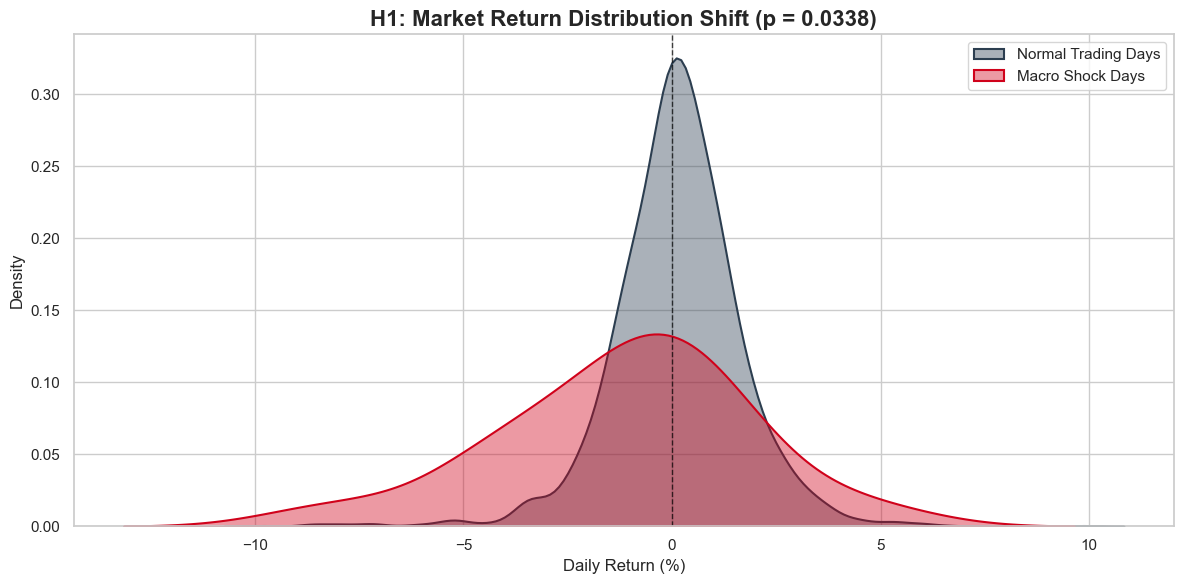

In [2]:
# 1. Isolate Distributions
shocks = df[df['is_shock'] == 1]['daily_return_pct'].dropna()
normal = df[df['is_shock'] == 0]['daily_return_pct'].dropna()

# 2. Statistical Testing
u_stat, p_h1 = st.mannwhitneyu(shocks, normal, alternative='two-sided')

print("--- HYPOTHESIS 1: DISTRIBUTION SHIFT ---")
print("Test: Mann-Whitney U [Median(Shock) vs Median(Normal)]")
print(f"U-Statistic: {u_stat}")
print(f"P-Value:     {p_h1:.6e}")
if p_h1 < 0.05:
    print("✅ RESULT: Statistically Significant. The return distributions are fundamentally different.")
else:
    print("❌ RESULT: Not Statistically Significant.")

# 3. Visualization
plt.figure(figsize=(12, 6))

# Plot the density curves
sns.kdeplot(normal, label="Normal Trading Days", fill=True, color="#2C3E50", alpha=0.4, linewidth=1.5)
sns.kdeplot(shocks, label="Macro Shock Days", fill=True, color="#D0021B", alpha=0.4, linewidth=1.5)

# Formatting
plt.title(f"H1: Market Return Distribution Shift (p = {p_h1:.4f})", fontsize=16, fontweight='bold')
plt.xlabel("Daily Return (%)", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1, alpha=0.7)
plt.legend(frameon=True, fontsize=11)

plt.tight_layout()
plt.show()

## H2 – Volatility Expansion Under Stress
**Hypothesis**
* **H2:** Macroeconomic and geopolitical shocks significantly increase the volatility (variance) of the market compared to normal trading conditions.
* **H0:** The variance of returns on shock days is equal to the variance on normal days.

**Methodological Approach:**
To test for the expansion of market risk, we need to compare the variance of the two groups. We use **Levene's Test** for equality of variances. Levene's test is deliberately chosen over Bartlett's test because it is highly resistant to non-normal distributions, making it the standard choice for testing financial time-series data.


In [3]:
# 1. Statistical Testing
v_stat, p_val_h2 = st.levene(shocks, normal)

print("--- HYPOTHESIS 2: VOLATILITY EXPANSION ---")
print("Test: Levene's Test [Equality of Variances: σ²_shock = σ²_normal]")
print(f"Levene Statistic: {v_stat:.4f}")
print(f"P-Value:          {p_val_h2:.6e}")

if p_val_h2 < 0.05:
    volatility_multiplier = shocks.std() / normal.std()
    print("✅ RESULT: Strong statistical proof that shocks structurally increase market risk.")
    print(f"Insight: Shock day volatility is {volatility_multiplier:.2f}x higher than baseline trading days.")
else:
    print("❌ RESULT: Variance is not significantly different.")

--- HYPOTHESIS 2: VOLATILITY EXPANSION ---
Test: Levene's Test [Equality of Variances: σ²_shock = σ²_normal]
Levene Statistic: 17.5025
P-Value:          2.957042e-05
✅ RESULT: Strong statistical proof that shocks structurally increase market risk.
Insight: Shock day volatility is 1.91x higher than baseline trading days.


## H3 – The Impact of Shock Severity on Returns
**Hypothesis**
* **H3:** The magnitude of the market reaction is directly dependent on the categorized severity of the shock (e.g., Moderate vs. High vs. Extreme).
* **H0:** The assigned severity level of an external shock does not statistically explain the variance in daily returns.

We use the isolated shock days merged with the `severity` categorical variable.

**Methodological Approach:**
We estimate the linear relationship using a **One-Way ANOVA** (Analysis of Variance):
`daily_return_pct ~ C(severity)`
This allows us to test if the mean returns differ significantly across the distinct severity categories. A high p-value would indicate that once a shock occurs, the market reacts indiscriminately, regardless of the event's initial classification.

--- HYPOTHESIS 3: SEVERITY IMPACT ---
Formula: Return ~ β0 + β1(Moderate) + β2(High) + β3(Extreme)
                 sum_sq    df         F    PR(>F)
C(severity)   10.769608   2.0  0.583973  0.569867
Residual     138.314779  15.0       NaN       NaN

❌ RESULT: Severity does NOT statistically explain the variance in return % (p = 0.5699).
Insight: Once an external shock hits, market panic is indiscriminate. An event deemed 'Moderate' can trigger a sell-off just as severe as an 'Extreme' event.


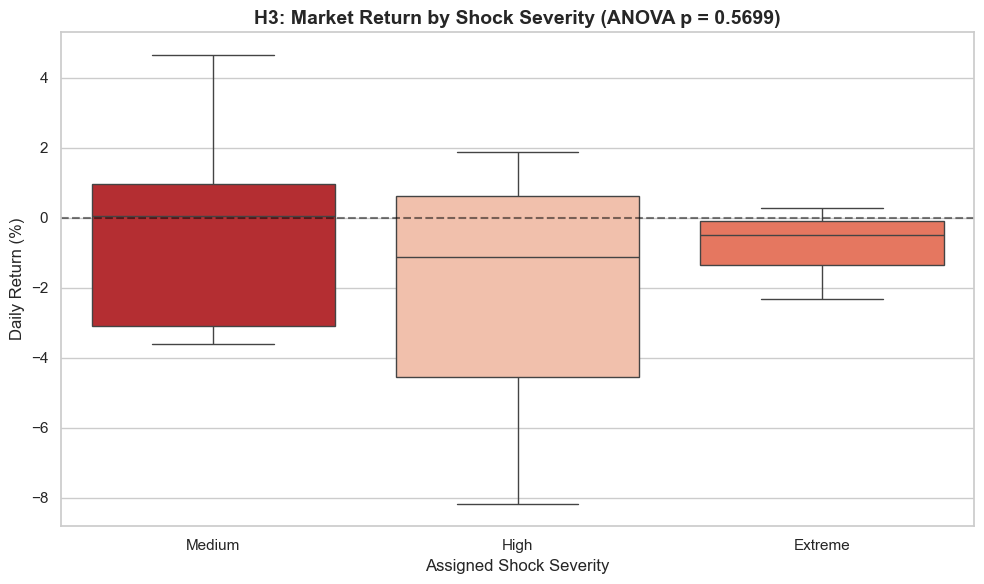

In [4]:
# 1. Data Preparation (Isolate only the shock days)
df_s = df[df['is_shock'] == 1].copy()

# 2. Statistical Testing (One-Way ANOVA)
model = smf.ols('daily_return_pct ~ C(severity)', data=df_s).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

print("--- HYPOTHESIS 3: SEVERITY IMPACT ---")
print("Formula: Return ~ β0 + β1(Moderate) + β2(High) + β3(Extreme)")
print(anova_table)

# Extract P-Value
p_val_h3 = anova_table.loc['C(severity)', 'PR(>F)']

if p_val_h3 > 0.05:
    print(f"\n❌ RESULT: Severity does NOT statistically explain the variance in return % (p = {p_val_h3:.4f}).")
    print("Insight: Once an external shock hits, market panic is indiscriminate. An event deemed 'Moderate' can trigger a sell-off just as severe as an 'Extreme' event.")
else:
    print("\n✅ RESULT: Severity statistically explains return variance.")

# 3. Visualization
plt.figure(figsize=(10, 6))

# Define order of severity if you want a clean progression on the X-axis
severity_order = ['Medium', 'High', 'Extreme'] 

sns.boxplot(
    data=df_s, 
    x='severity', 
    y='daily_return_pct', 
    hue='severity', 
    palette='Reds', 
    order=[s for s in severity_order if s in df_s['severity'].unique()], # Ensures only existing categories are plotted
    legend=False
)

# Formatting
plt.title(f"H3: Market Return by Shock Severity (ANOVA p = {p_val_h3:.4f})", fontsize=14, fontweight='bold')
plt.xlabel("Assigned Shock Severity", fontsize=12)
plt.ylabel("Daily Return (%)", fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, alpha=0.5)

plt.tight_layout()
plt.show()

## H4 – Shock Persistence and the "Hangover" Effect
**Hypothesis**
* **H4:** The market exhibit a "hangover" effect, where negative pressure on returns continues into the trading session immediately following a macro-shock (T+1).
* **H0:** The BIST 100 is "Informationally Efficient," meaning it fully absorbs the shock within a single trading session, and returns on Day T+1 show no systematic difference from normal trading days.

**Methodological Approach:**
This test utilizes **Lagged Variables** to observe temporal spillover. We shift the shock indicator by one period to isolate Day T+1 (the day after each event). We then compare the returns of these "hangover" days against a baseline of pure normal days (days that are neither a shock day nor the day after a shock).

Statistical significance here would suggest that external shocks trigger short-term trends or "panic cycles" that do not dissipate instantly.

**Test Specification:** Compare $Returns_{T+1}$ (lagged shock impact) against a baseline of pure normal trading days using the **Mann-Whitney U Test** to identify temporal spillover of market panic.

--- HYPOTHESIS 4: SHOCK PERSISTENCE (T+1) ---
Test: Lagged Mann-Whitney U [Returns_T+1 vs Returns_Normal]
P-Value: 6.993303e-01
❌ RESULT: No Persistence. The BIST 100 absorbs shocks within a single trading session.


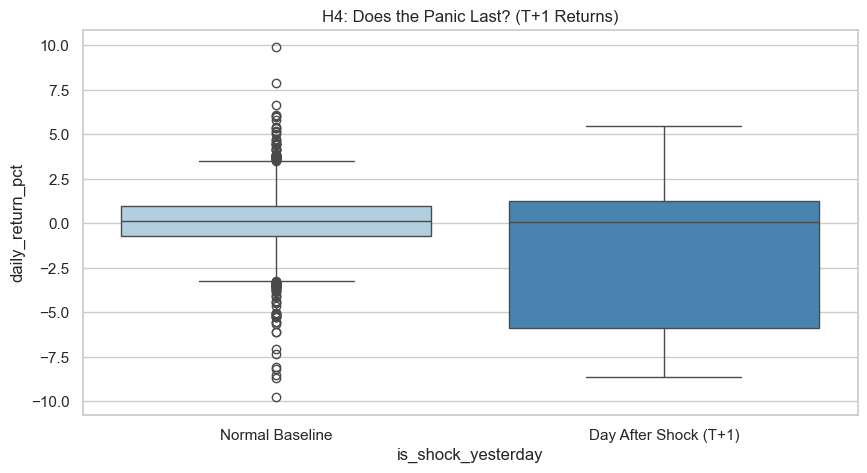

In [5]:
# 1. Create a Lagged Shock column (Day T+1)
df['is_shock_yesterday'] = df['is_shock'].shift(1).fillna(0)

# 2. Isolate Distributions
# We compare the day AFTER a shock vs. purely Normal Days
day_after_shocks = df[df['is_shock_yesterday'] == 1]['daily_return_pct'].dropna()
pure_normal = df[(df['is_shock'] == 0) & (df['is_shock_yesterday'] == 0)]['daily_return_pct'].dropna()

# 3. Statistical Testing (Mann-Whitney U)
u_stat_h4, p_val_h4 = st.mannwhitneyu(day_after_shocks, pure_normal, alternative='two-sided')

print("--- HYPOTHESIS 4: SHOCK PERSISTENCE (T+1) ---")
print("Test: Lagged Mann-Whitney U [Returns_T+1 vs Returns_Normal]")
print(f"P-Value: {p_val_h4:.6e}")

if p_val_h4 < 0.05:
    print("✅ RESULT: Significant Persistence. Shocks trigger trends that last beyond the initial day.")
else:
    print("❌ RESULT: No Persistence. The BIST 100 absorbs shocks within a single trading session.")

# 4. Visualization
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['is_shock_yesterday'], y=df['daily_return_pct'], palette='Blues', hue=df['is_shock_yesterday'], legend=False)
plt.xticks([0, 1], ['Normal Baseline', 'Day After Shock (T+1)'])
plt.title("H4: Does the Panic Last? (T+1 Returns)")
plt.show()